Ejercicio de clase de creación completo de un pipeline de Machine Learning. Los pasos son: La carga de los datos, limpieza y preprocesamiento, ingenieria y seleccion de variables, eleccion de variables, division train/test, crossvalidation, balanceo, prueba de modelos supervisados y no supervisados 

Paso 1: Carga de los datos

In [363]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import ssl
import urllib.request
import seaborn as sns
from scipy.stats import mstats, chi2
from scipy.spatial.distance import mahalanobis
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from scipy import stats

# Descarga directa sin ucimlrepo
ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

url = "https://archive.ics.uci.edu/static/public/477/data.csv"
with urllib.request.urlopen(url, context=ctx) as r:
    df = pd.read_csv(r)

df = df.rename(columns={
    'X1 transaction date':                    'Transaction Date',
    'X2 house age':                           'House Age',
    'X3 distance to the nearest MRT station': 'Distance to MRT',
    'X4 number of convenience stores':        'Number of Stores',
    'X5 latitude':                            'Latitude',
    'X6 longitude':                           'Longitude',
    'Y house price of unit area':             'House Price of Unit Area'
}).drop(columns=['No'])

X = df.drop(columns=['House Price of Unit Area'])
y = df['House Price of Unit Area']

print(df.shape)
print(df.dtypes)

(414, 7)
Transaction Date            float64
House Age                   float64
Distance to MRT             float64
Number of Stores              int64
Latitude                    float64
Longitude                   float64
House Price of Unit Area    float64
dtype: object


In [364]:
X


,Transaction Date,House Age,Distance to MRT,Number of Stores,Latitude,Longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245
...,...,...,...,...,...,...
409,2013.000,13.7,4082.01500,0,24.94155,121.50381
410,2012.667,5.6,90.45606,9,24.97433,121.54310
411,2013.250,18.8,390.96960,7,24.97923,121.53986
412,2013.000,8.1,104.81010,5,24.96674,121.54067


Paso 2: Limpieza y preprocesamiento de datos

En este paso tendremos que hacer la busqueda exploratoria del DataFrame en busca de anormalidades. El import que UCIMLRepository nos daba como base nos separa x de y. Ahora los uniremos para hacer el analisis exploratorio completo mas sencillo

Una vez unificados vamos a pasar al análisis exploratorio completo

In [365]:
df.dtypes

Transaction Date            float64
House Age                   float64
Distance to MRT             float64
Number of Stores              int64
Latitude                    float64
Longitude                   float64
House Price of Unit Area    float64
dtype: object

In [366]:
df.describe()

,Transaction Date,House Age,Distance to MRT,Number of Stores,Latitude,Longitude,House Price of Unit Area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [367]:
df.isnull().sum()

Transaction Date            0
House Age                   0
Distance to MRT             0
Number of Stores            0
Latitude                    0
Longitude                   0
House Price of Unit Area    0
dtype: int64

In [368]:
df.isna().sum()

Transaction Date            0
House Age                   0
Distance to MRT             0
Number of Stores            0
Latitude                    0
Longitude                   0
House Price of Unit Area    0
dtype: int64

Hemos comprobado el tipo de los datos asi como sus distribuciones principales. Ahora lo que haremos sera realizar una visualización de los datos para poder observar la presencia de algun outlier

In [369]:
X.columns.tolist()

['Transaction Date',
 'House Age',
 'Distance to MRT',
 'Number of Stores',
 'Latitude',
 'Longitude']

In [370]:
X = df.drop(columns=['House Price of Unit Area']).copy()
y = df['House Price of Unit Area'].copy()

In [371]:
X

,Transaction Date,House Age,Distance to MRT,Number of Stores,Latitude,Longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245
...,...,...,...,...,...,...
409,2013.000,13.7,4082.01500,0,24.94155,121.50381
410,2012.667,5.6,90.45606,9,24.97433,121.54310
411,2013.250,18.8,390.96960,7,24.97923,121.53986
412,2013.000,8.1,104.81010,5,24.96674,121.54067


In [372]:
y

0      37.9
1      42.2
2      47.3
3      54.8
4      43.1
       ... 
409    15.4
410    50.0
411    40.6
412    52.5
413    63.9
Name: House Price of Unit Area, Length: 414, dtype: float64

In [373]:
print(df.columns.tolist())

['Transaction Date', 'House Age', 'Distance to MRT', 'Number of Stores', 'Latitude', 'Longitude', 'House Price of Unit Area']


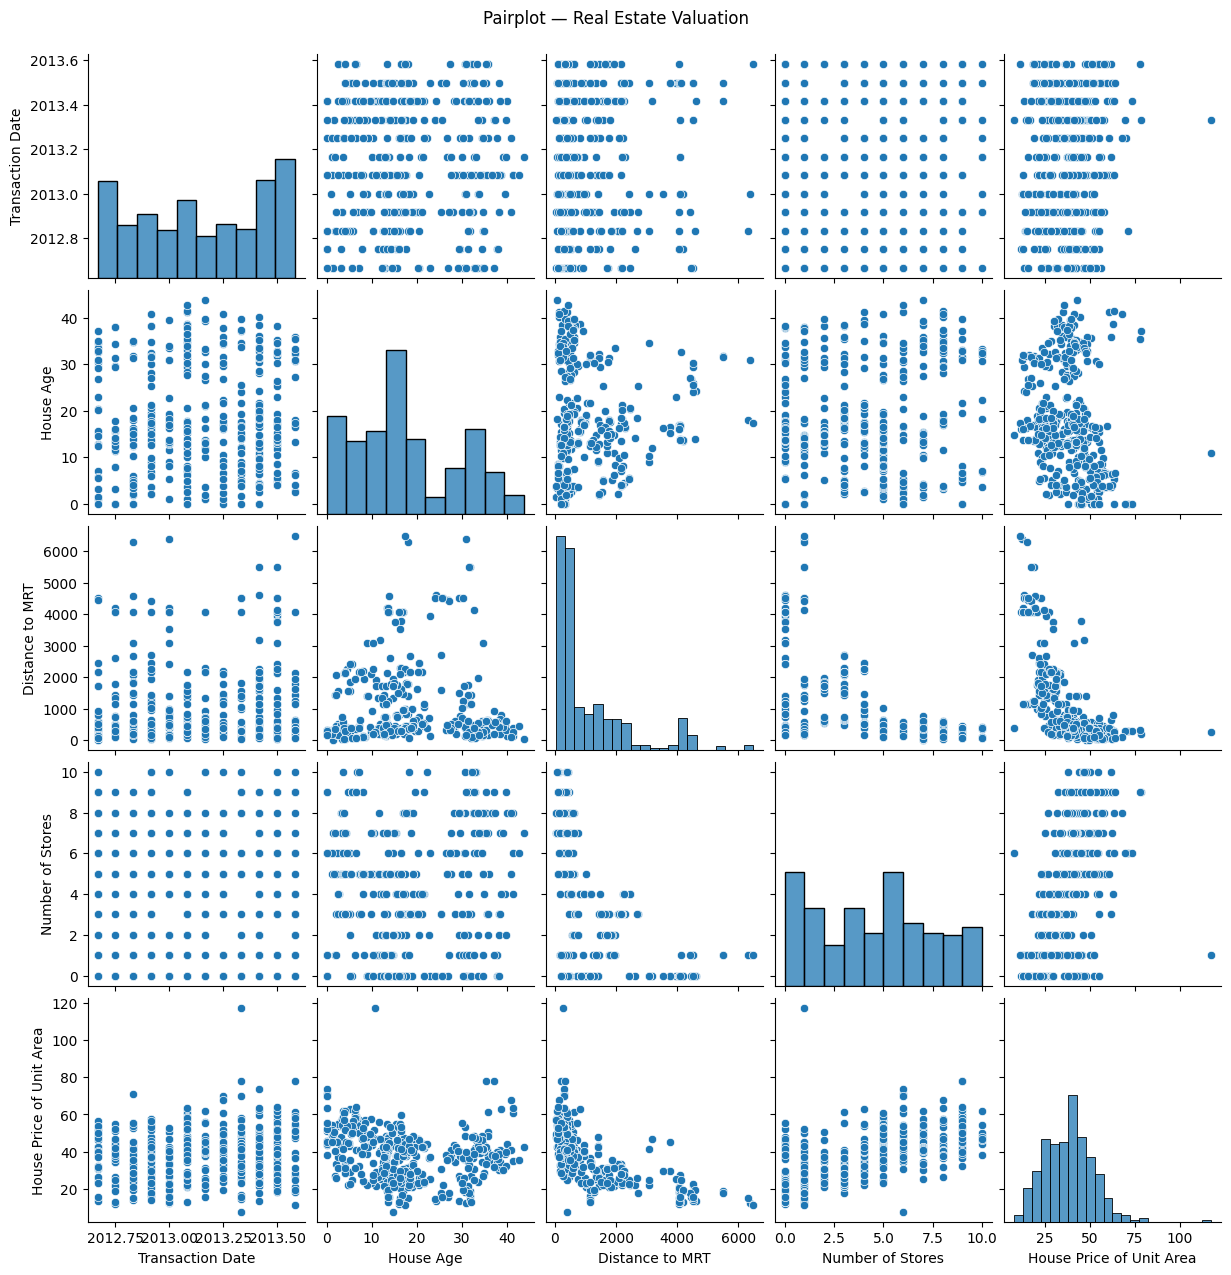

In [374]:
sns.pairplot(df[["Transaction Date", "House Age", "Distance to MRT", "Number of Stores", "House Price of Unit Area"]])
plt.suptitle('Pairplot — Real Estate Valuation', y=1.02)
plt.show()

Podemos hacer varias observaciones interesantes: 

Primero analizamos el eje diagonal, es decir, las variables por sí mismas:

1. Las distribuciones de la edad de las casas y el número de tiendas no cuentan con sesgos especialmente importantes. 
2. El precio por unidad de área presenta un sesgo muy pequeño en la parte derecha de la cola, aunque esperado por la naturaleza propia del mercado inmobiliario, donde las viviendas con m2 más caros que la media son escasos. Además, tiene datos anómalos en torno a 120 que observaremos en el paso de tratamiento de outliers y propondremos varios métodos para ello pues está desviando la distribución hacia la derecha.
3. En la distancia al metro notamos que la mayoría de las casas se encuentran cerca del centro. Los datos se encuentran fuertemenete sesgados hacia la derecha. Se observa, además, una distribución de caracteristicas logaritmicas que tiende hacia la izquierda. Habra que realizar una transformacion a los datos dado que muchos algoritmos asumen cierta simetría en las features.

Pese a que se vean los sesgos a simple vista calcularlos tampoco está de más. 

Observemos los sesgos de la distribución de los distintos datos. El sesgo hará que la mediana y la media se separen mucho entre sí. Por otro lado, el SKEW es el medidor de sesgo. Si este es mayor que cero el sesgo esta hacia la derecha y si es menor hacia la izquierda. El sesgo se considera importante si éste es superior a 1 por la derecha o a -1 por la izquierda

In [375]:
cols = ['House Price of Unit Area', 'Distance to MRT', 'House Age', 'Number of Stores']

for col in cols:
    print(f"{'─'*40}")
    print(f"Variable: {col}")
    print(f"  Media:   {df[col].mean():.2f}")
    print(f"  Mediana: {df[col].median():.2f}")
    print(f"  Sesgo:   {df[col].skew():.2f}")

────────────────────────────────────────
Variable: House Price of Unit Area
  Media:   37.98
  Mediana: 38.45
  Sesgo:   0.60
────────────────────────────────────────
Variable: Distance to MRT
  Media:   1083.89
  Mediana: 492.23
  Sesgo:   1.89
────────────────────────────────────────
Variable: House Age
  Media:   17.71
  Mediana: 16.10
  Sesgo:   0.38
────────────────────────────────────────
Variable: Number of Stores
  Media:   4.09
  Mediana: 4.00
  Sesgo:   0.15


Lo que observamos es que todos tienen sesgo a la derecha. House Age, House Price of Unit Area y Number of Stores cuentan con sesgo menor a 1, es decir, sesgo no relevante. Sin embargo, el sesgo de Distance to MRT es de 1.89, muy alto. Esta distribución fuertemente sesgada y de tendencia logaritmica nos sugiere que una transformación logarítmica podría ser beneficiosa antes de introducir esta variable en los modelos.

Lo añadiremos más adelante a la pipeline para que sea consistente en producción.

Por otro lado, ahora procederemos al conjunto de datos anomalos que dijimos antes en la variable target. Observemos

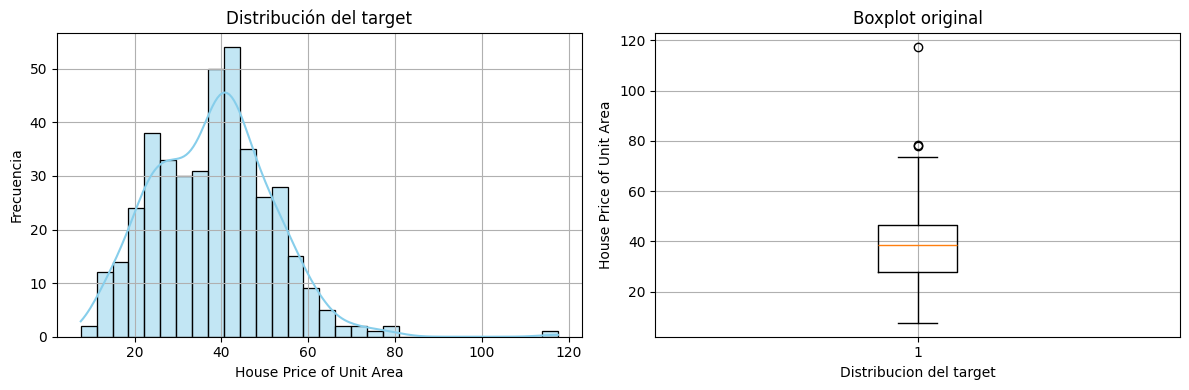

In [376]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
sns.histplot(df['House Price of Unit Area'], bins=30, kde=True, 
             color='skyblue', ax=axes[0])
axes[0].set_title('Distribución del target')
axes[0].set_xlabel('House Price of Unit Area')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(True)

# Boxplot
axes[1].boxplot(df['House Price of Unit Area'])
axes[1].set_title('Boxplot original')
axes[1].set_ylabel('House Price of Unit Area')
axes[1].set_xlabel("Distribucion del target")
axes[1].grid(True)

plt.tight_layout()
plt.show()


Un outlier es un dato anómalo. Esto no quiere decir que sea malo, simplemente que es un dato extraño respecto a la distribucion de los datos. Lo primero que deberiamos plantearnos sería:

1. Es este outlier un error de recogida porque su dato sea muy poco plausible?
2. Es este outlier un problema para el modelo que queramos escoger?
3. En caso de querer tratar este outlier, cuales son los métodos que deberiamos implementar para él?

Primero le realizaremos unos cuantos tests. El objetivo es observar si las variables actuales son capaces de explicar porqué este dato cuenta con el precio que cuenta. Es decir: ahondar en su naturaleza para así plantearnos como tratarlo

Miremos primero los cinco primeros por orden de precio del metro cuadrado para ver si a simple vista vemos alguna anomalia

In [377]:
df.nlargest(5, 'House Price of Unit Area')

,Transaction Date,House Age,Distance to MRT,Number of Stores,Latitude,Longitude,House Price of Unit Area
270,2013.333,10.8,252.5822,1,24.97460,121.53046,117.5
220,2013.333,37.2,186.5101,9,24.97703,121.54265,78.3
312,2013.583,35.4,318.5292,9,24.97071,121.54069,78.0
166,2013.417,0.0,292.9978,6,24.97744,121.54458,73.6
105,2012.833,0.0,292.9978,6,24.97744,121.54458,71.0


Observamos algo muy curioso: Parece que el outlier de la variabel target no es un conjunto de datos anomalos, sino únicamente uno, el ID 270. Ahora lo observaremos mas de cerca bajo lupa

In [378]:
df.iloc[270]

Transaction Date            2013.33300
House Age                     10.80000
Distance to MRT              252.58220
Number of Stores               1.00000
Latitude                      24.97460
Longitude                    121.53046
House Price of Unit Area     117.50000
Name: 270, dtype: float64

Ya los datos a primera vista parecen extraños. No parece que exista alguna razón directa por la que la propiedad tenga ese precio: pocas tiendas alrededor por ejemplo. Sin embargo, no sabemos dentro de la distribución cuánto. Realizaremos varias pruebas.

In [379]:
# Para la fila 270 (precio 117.5):
idx = 270
row = df.loc[idx]

# Comprueba cada feature individualmente
for col in ['House Age', 'Distance to MRT', 'Number of Stores']:
    pct = (df[col] < row[col]).mean() * 100
    print(f"{col}: valor={row[col]:.1f} | percentil={pct:.1f}%")

print(f"\nPrecio: {row['House Price of Unit Area']} | percentil={(df['House Price of Unit Area'] < row['House Price of Unit Area']).mean()*100:.1f}%")

House Age: valor=10.8 | percentil=28.0%
Distance to MRT: valor=252.6 | percentil=19.8%
Number of Stores: valor=1.0 | percentil=16.2%

Precio: 117.5 | percentil=99.8%


In [380]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

features = ['House Age', 'Distance to MRT', 'Number of Stores']

# Modelo CON el punto
X_con = df[features].values
y_con = df['House Price of Unit Area'].values
lr_con = LinearRegression().fit(X_con, y_con)

# Modelo SIN el punto
mask = df.index != 270
X_sin = df[features][mask].values
y_sin = df['House Price of Unit Area'][mask].values
lr_sin = LinearRegression().fit(X_sin, y_sin)

# ¿Cuánto cambian los coeficientes?
print("Coeficientes CON el punto:", lr_con.coef_)
print("Coeficientes SIN el punto:", lr_sin.coef_)
print("Diferencia %:", 
      np.abs((lr_con.coef_ - lr_sin.coef_) / lr_con.coef_) * 100)

# Cook's Distance manual
residuos = y_con - lr_con.predict(X_con)
leverage = np.diag(X_con @ np.linalg.pinv(X_con.T @ X_con) @ X_con.T)
p = X_con.shape[1]
mse = np.mean(residuos**2)
cooks = (residuos**2 * leverage) / (p * mse * (1 - leverage)**2)

print(f"\nCook's Distance del punto 270: {cooks[270]:.4f}")
print(f"Umbral problemático (4/n):      {4/len(df):.4f}")
print(f"¿Es influyente?: {cooks[270] > 4/len(df)}")

Coeficientes CON el punto: [-0.25285583 -0.00537913  1.29744248]
Coeficientes SIN el punto: [-0.24544916 -0.00508057  1.44066512]
Diferencia %: [ 2.92920728  5.55029706 11.03884346]

Cook's Distance del punto 270: 0.0205
Umbral problemático (4/n):      0.0097
¿Es influyente?: True


In [381]:
# Busca vecinos cercanos geográficamente con características similares
from sklearn.neighbors import NearestNeighbors
import pandas as pd

X_geo = df[['Latitude', 'Longitude', 'House Age', 'Number of Stores']].copy()

nn = NearestNeighbors(n_neighbors=6)
nn.fit(X_geo)

# Los 5 vecinos más similares al punto 270
distancias, indices = nn.kneighbors(X_geo.loc[[270]])

vecinos = df.iloc[indices[0]]
print(vecinos[['House Age', 'Distance to MRT', 
               'Number of Stores', 'House Price of Unit Area']])

     House Age  Distance to MRT  Number of Stores  House Price of Unit Area
270       10.8         252.5822                 1                     117.5
356       10.3         211.4473                 1                      45.3
208       11.5        1360.1390                 1                      26.2
240       11.0        1712.6320                 2                      28.8
60        11.0        1931.2070                 2                      21.3
144       11.9        1360.1390                 1                      28.4


Esto es lo que nos devuelve: 

Posicion 83 de 414 y percentil 19.8% respecto a distancia al metro. Es decir, hay 82 casas más cerca del metro

Posicion 90.5 de 414 y percentil 16.2% en el ranking de tiendas. Es decir, hay 323.5 casas con mayor numero de tiendas alrededor. El '5 será porque al ser un número entero varias de ellas compartirán posición.

Posicion 414 de 414 y percentil 99.8%. Es decir, es la casa más cara de todo el Dataset y ese 0.2% de la distribucion que no se encuentra en el percentil 98.8 es la propia casa.

Posicion 117 de 414 y percentil 28%. Es decir, 297 casas son mas viejas. 

A simple vista parece que su lugar en la distribucion no corresponde con ninguna explicacion logica de su precio. El siguiente paso logico parece escudriñar los activos mas caros por metro cuadrado para ver de forma directa las irregularidades de esta vivienda. 

Volviendo al outlier 270: Lo unico que se puede afirmar con certeza es que las variables actuales no explican su precio. Este debe ser causado por alguna variable escondida (Metros cuadrados, orientacion, materiales constructivos, amueblamiento, urbanizacion de lujo...) de la cual no disponemos y que hace imposible que seamos capaces de captar de forma correcta para el modelo cuales son los patrones que influyen en su subida de precios, por lo que es un dato que el modelo no podrá generalizar. Ante esta problemática, tenemos diferentes formas de tratar con el dato:

## Decisión de exclusión — Índice 270

Se excluye la observación 270 (precio: 117.5 NTD/ping) por las
siguientes razones objetivas y auditables:

1. **Incoherencia features-target:** Las tres features están en
   percentiles 16-28%, mientras el precio está en percentil 99.8%.
   No existe combinación similar en el dataset que justifique
   este nivel de precio.

2. **Vecino más cercano contradictorio:** El índice 356 tiene
   características prácticamente idénticas (edad 10.3, distancia
   211m, 1 tienda) y un precio de 45.3, el 38% del valor
   de la observación excluida.

3. **Influencia estadística excesiva:** Cook's Distance = 0.0205,
   el doble del umbral recomendado (4/n = 0.0097). Su presencia
   desplaza el coeficiente de Number of Stores un 11%.

4. **Factor latente no capturado:** La causa más probable es un
   atributo no registrado en el dataset (reforma integral,
   características físicas especiales, condición de venta
   atípica). Al no ser modelable, su inclusión introduce
   ruido sistemático.

Acción: excluida del entrenamiento. Guardada en
anomalias_para_revision.xlsx para revisión con el cliente.

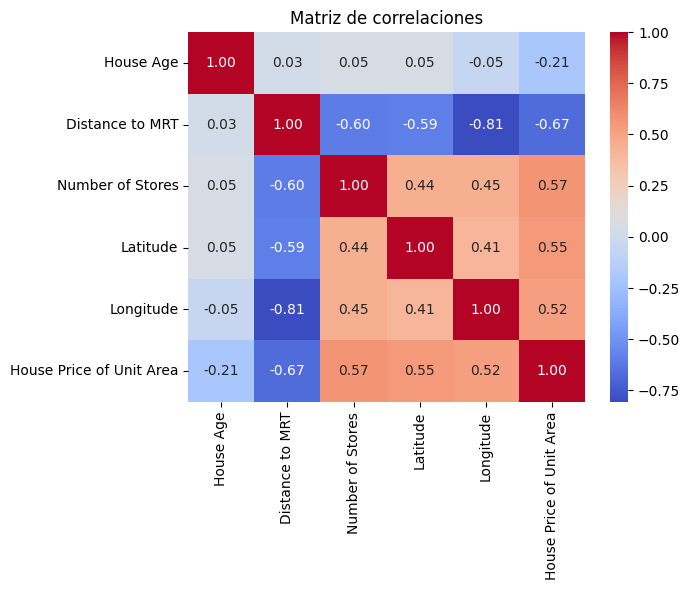

In [382]:
sns.heatmap(df[['House Age', 'Distance to MRT', 'Number of Stores', 
                'Latitude', 'Longitude', 'House Price of Unit Area']].corr(), 
            annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de correlaciones')
plt.show()

In [383]:
eliminados = df[df['House Price of Unit Area'] >= 117.5].copy()
eliminados.to_excel("anomalias_para_revision.xlsx", index=False)
df = df[df['House Price of Unit Area'] < 117.5].copy()

Los outliers se tratan despues de hacer el train test split. En este caso, al tener la importante variable temporal de la fecha tenemos primero que hacer aquí un train test split temporal para comenzar a tratar los diferentes outliers. El indice 270 es una decision de negocio mas que un outlier en si por lo que su exclusion antes del train test no importa tant, pues su incoherencia estaba en la variable target.

Ahora hablemos sobre los otros tipos de outliers: los relacionados a las variables inconexas o outliers mutivariante. Para ello probaremos isolation forest y la distancia de moholarobis. Lo que haremos será utilizarlos de forma conjunta para tratar de ser lo mas precisos posible

Isolation Forest: Detecta outliers multivariante, es decir, combinaciones anómalas de variables. Es el método más sofisticado pero también el menos interpretable: puede eliminar filas cuya razón no es evidente a simple vista, lo cual dificulta la justificación ante el cliente.

In [384]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer

df = df.sort_values('Transaction Date').reset_index(drop=True)
df['mrt_stores_score'] = df['Number of Stores'] / np.log1p(df['Distance to MRT'])

cutoff = int(len(df) * 0.70)
tscv   = TimeSeriesSplit(n_splits=3, test_size=60)

k óptimo KMeans: 8  (Silhouette=0.520  DB=0.638)


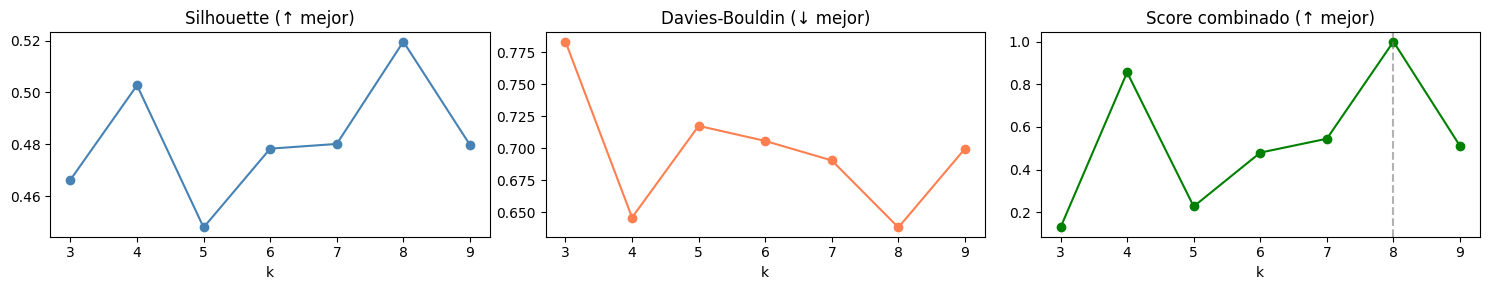

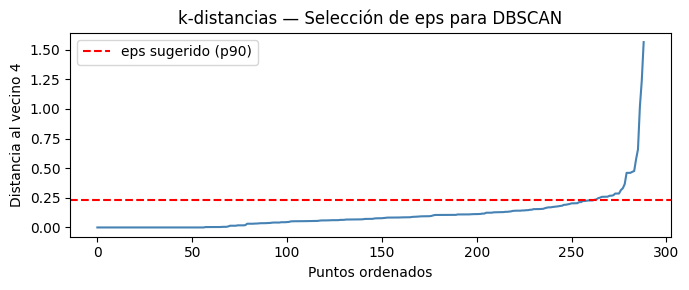

eps seleccionado automáticamente: 0.2277

KMeans  → k=8  | Silhouette=0.5196
DBSCAN  → clusters=11 | Silhouette (sin ruido)=0.3147 | Penalizado=0.2994 | Ruido=4.8%

→ Criterios DBSCAN cumplidos: False
→ MÉTODO GANADOR: KMeans


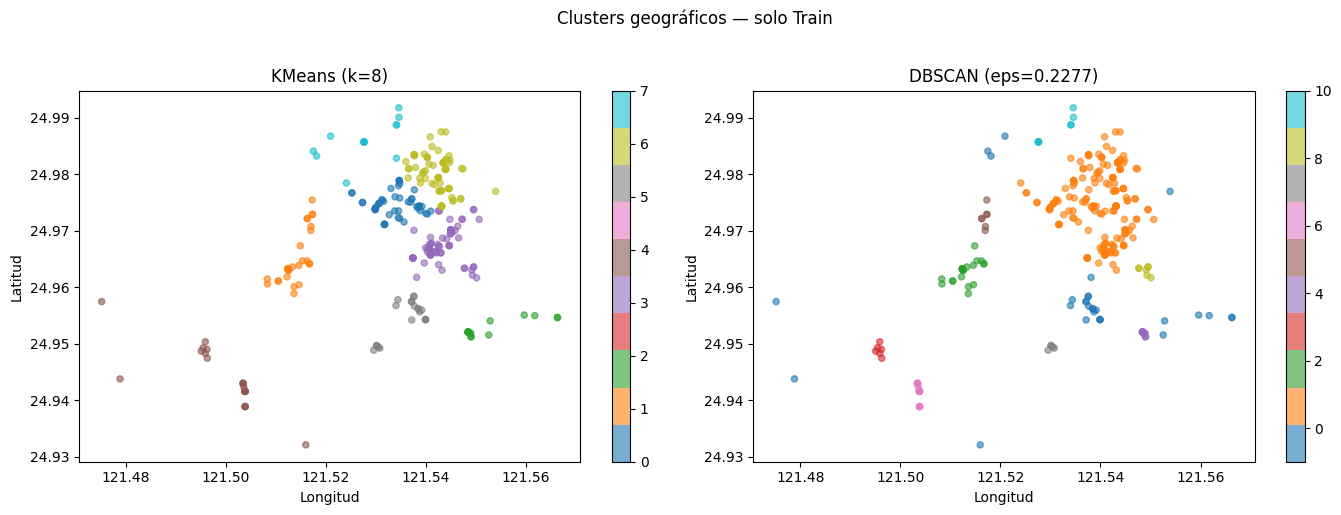

In [385]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── 1a. Preparamos las coordenadas (solo train para evitar leakage)
coords_train = df.iloc[:cutoff][['Latitude', 'Longitude']].values
coords_full  = df[['Latitude', 'Longitude']].values

scaler_geo = StandardScaler()
coords_train_sc = scaler_geo.fit_transform(coords_train)   # fit solo en train
coords_full_sc  = scaler_geo.transform(coords_full)        # transform en todo

# ── 1b. KMeans: elegimos k por Silhouette + Davies-Bouldin
k_range = range(3, 10)
sil_scores, db_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(coords_train_sc)
    sil_scores.append(silhouette_score(coords_train_sc, labels))
    db_scores.append(davies_bouldin_score(coords_train_sc, labels))

# Normalizamos y combinamos (mayor Silhouette mejor, menor DB mejor)
sil_norm = np.array(sil_scores)
sil_norm = (sil_norm - sil_norm.min()) / (np.ptp(sil_norm) + 1e-9)
db_norm  = np.array(db_scores)
db_norm  = 1 - (db_norm - db_norm.min()) / (np.ptp(db_norm) + 1e-9)
combined = (sil_norm + db_norm) / 2

k_opt = list(k_range)[combined.argmax()]
print(f"k óptimo KMeans: {k_opt}  (Silhouette={sil_scores[combined.argmax()]:.3f}  DB={db_scores[combined.argmax()]:.3f})")

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].plot(k_range, sil_scores, 'o-', color='steelblue')
axes[0].set_title('Silhouette (↑ mejor)'); axes[0].set_xlabel('k')
axes[1].plot(k_range, db_scores, 'o-', color='coral')
axes[1].set_title('Davies-Bouldin (↓ mejor)'); axes[1].set_xlabel('k')
axes[2].plot(k_range, combined, 'o-', color='green')
axes[2].axvline(k_opt, color='gray', linestyle='--', alpha=0.6)
axes[2].set_title('Score combinado (↑ mejor)'); axes[2].set_xlabel('k')
plt.tight_layout(); plt.show()

# ── 1c. Fit final KMeans con k_opt
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
km_final.fit(coords_train_sc)
sil_km = silhouette_score(coords_train_sc, km_final.labels_)

# ── 1d. DBSCAN: selección automática de eps (percentil 90 de k-distancias)
k_nn = 4
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(coords_train_sc)
distancias_nn, _ = nbrs.kneighbors(coords_train_sc)

plt.figure(figsize=(7, 3))
plt.plot(np.sort(distancias_nn[:, -1]), color='steelblue')
plt.axhline(y=np.percentile(distancias_nn[:, -1], 90),
            color='red', linestyle='--', label='eps sugerido (p90)')
plt.title('k-distancias — Selección de eps para DBSCAN')
plt.xlabel('Puntos ordenados'); plt.ylabel(f'Distancia al vecino {k_nn}')
plt.legend(); plt.tight_layout(); plt.show()

eps_opt = float(np.percentile(distancias_nn[:, -1], 90))
print(f"eps seleccionado automáticamente: {eps_opt:.4f}")

# ── 1e. DBSCAN final
db_final = DBSCAN(eps=eps_opt, min_samples=4)
db_final.fit(coords_train_sc)

labels_db = db_final.labels_
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
pct_ruido = (labels_db == -1).sum() / len(labels_db)

if n_clusters_db >= 2:
    mask_no_ruido = labels_db != -1
    sil_db = silhouette_score(coords_train_sc[mask_no_ruido], labels_db[mask_no_ruido])
    sil_db_penalizado = sil_db * (1 - pct_ruido)
else:
    sil_db = 0.0
    sil_db_penalizado = 0.0

print(f"\nKMeans  → k={k_opt}  | Silhouette={sil_km:.4f}")
print(f"DBSCAN  → clusters={n_clusters_db} | Silhouette (sin ruido)={sil_db:.4f} "
      f"| Penalizado={sil_db_penalizado:.4f} | Ruido={pct_ruido*100:.1f}%")

# ── 1f. Decisión automática con criterios explícitos
dbscan_valido = (
    n_clusters_db >= 3
    and pct_ruido < 0.10
    and sil_db_penalizado > sil_km
)
metodo_ganador = "DBSCAN" if dbscan_valido else "KMeans"

print(f"\n→ Criterios DBSCAN cumplidos: {dbscan_valido}")
print(f"→ MÉTODO GANADOR: {metodo_ganador}")

# ── 1g. Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(coords_train[:, 1], coords_train[:, 0],
                     c=km_final.labels_, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title(f'KMeans (k={k_opt})')
axes[0].set_xlabel('Longitud'); axes[0].set_ylabel('Latitud')
plt.colorbar(sc, ax=axes[0])

sc2 = axes[1].scatter(coords_train[:, 1], coords_train[:, 0],
                      c=labels_db, cmap='tab10', alpha=0.6, s=20)  # ← labels_db no labels_db_train
axes[1].set_title(f'DBSCAN (eps={eps_opt:.4f})')
axes[1].set_xlabel('Longitud'); axes[1].set_ylabel('Latitud')
plt.colorbar(sc2, ax=axes[1])

plt.suptitle('Clusters geográficos — solo Train', y=1.02)
plt.tight_layout(); plt.show()

In [386]:
if metodo_ganador == "KMeans":
    # predict usa el modelo fiteado solo en train → no hay leakage
    cluster_labels_full = km_final.predict(coords_full_sc)
else:
    # DBSCAN no tiene predict nativo; usamos NearestNeighbors para asignar test
    # a sus clusters más cercanos (sin refitear)
    from sklearn.neighbors import KNeighborsClassifier
    knn_assign = KNeighborsClassifier(n_neighbors=3)
    mask_clean = labels_db != -1
    knn_assign.fit(coords_train_sc[mask_clean], labels_db[mask_clean])
 
    cluster_labels_train = np.where(
        labels_db != -1,
        labels_db,
        knn_assign.predict(coords_train_sc)       # asigna los ruido al vecino más cercano
    )
    cluster_labels_test = knn_assign.predict(coords_full_sc[cutoff:])
    cluster_labels_full = np.concatenate([cluster_labels_train, cluster_labels_test])
 
df['geo_cluster'] = cluster_labels_full.astype(str)   # como categórica
 
# Precio medio por cluster (señal de negocio, calculado SOLO en train)
precio_medio_cluster = (
    df.iloc[:cutoff]
    .groupby('geo_cluster')['House Price of Unit Area']
    .mean()
    .rename('cluster_price_mean')
)

# Eliminamos la columna si ya existe para evitar duplicados
if 'cluster_price_mean' in df.columns:
    df = df.drop(columns=['cluster_price_mean'])
df = df.join(precio_medio_cluster, on='geo_cluster')
 
print("Distribución de clusters:")
print(df['geo_cluster'].value_counts().sort_index())
print("\nPrecio medio por cluster:")
print(df.groupby('geo_cluster')['House Price of Unit Area'].mean().sort_values())


Distribución de clusters:
geo_cluster
0     59
1     52
2     22
3     87
4     36
5     24
6    111
7     22
Name: count, dtype: int64

Precio medio por cluster:
geo_cluster
4    18.461111
2    25.718182
1    26.357692
5    35.241667
7    35.881818
3    40.652874
0    40.996610
6    48.779279
Name: House Price of Unit Area, dtype: float64


In [387]:
features = ["Transaction Date", 'House Age', 'Distance to MRT', 'Number of Stores',
            'Latitude', 'Longitude', 'mrt_stores_score','geo_cluster']
target   = 'House Price of Unit Area'

X = df[features]
y = df[target]

# Corte 70/30 + 3 splits

X_train     = X.iloc[:cutoff].reset_index(drop=True)
y_train     = y.iloc[:cutoff].reset_index(drop=True)
X_test = X.iloc[cutoff:].reset_index(drop=True)
y_test = y.iloc[cutoff:].reset_index(drop=True)

print(f"Desarrollo : {len(X_train)} filas | "
      f"{df['Transaction Date'].iloc[0]:.3f} → "
      f"{df['Transaction Date'].iloc[cutoff-1]:.3f}")
print(f"Hold-out   : {len(X_test)} filas | "
      f"{df['Transaction Date'].iloc[cutoff]:.3f} → "
      f"{df['Transaction Date'].iloc[-1]:.3f}")

X_train['house_age_c']  = X_train['House Age'] - X_train['House Age'].mean()
X_test['house_age_c']   = X_test['House Age'] - X_train['House Age'].mean()

Desarrollo : 289 filas | 2012.667 → 2013.417
Hold-out   : 124 filas | 2013.417 → 2013.583


In [388]:
clf = IsolationForest(contamination=0.03, random_state=42)
cols_num = X_train.select_dtypes(include='number').columns.tolist()
clf.fit(X_train[cols_num])

df_IF = X_train.copy()
scores      = clf.decision_function(X_train[cols_num])  # ← solo numéricas
predicciones = clf.predict(X_train[cols_num])   

df_IF["score_iforest"] = scores
df_IF["outlier_iforest"] = predicciones == -1

print(f"Outliers detectados por Isolation Forest: {df_IF['outlier_iforest'].sum()}")
print(f"Outliers por Isolation Forest:\n{df_IF[df_IF['outlier_iforest']]}")

Outliers detectados por Isolation Forest: 9
Outliers por Isolation Forest:
     Transaction Date  House Age  Distance to MRT  Number of Stores  Latitude  \
7            2012.667       29.4         4510.359                 1  24.94925   
15           2012.667       26.9         4449.270                 0  24.94898   
62           2012.833       10.3         3079.890                 0  24.95460   
79           2012.833       18.0         6306.153                 1  24.95743   
116          2012.917       27.1         4412.765                 1  24.95032   
138          2013.000        8.9         3078.176                 0  24.95464   
147          2013.000       30.9         6396.283                 1  24.94375   
265          2013.333       24.0         4527.687                 0  24.94741   
271          2013.333       25.6         4519.690                 0  24.94826   

     Longitude  mrt_stores_score geo_cluster  house_age_c  score_iforest  \
7    121.49542          0.118845      

La distancia de Mahalanobis: mide cuánto se aleja cada punto del centro de la distribución, teniendo en cuenta la correlación entre variables. A diferencia de la distancia euclidiana normal, escala según la forma real de los datos, así que no le afecta que unas variables tengan rangos mucho mayores que otras.

El umbral de Mahalanobis se basa en la distribución chi-cuadrado, que es la distribución teórica que siguen las distancias de Mahalanobis cuando los datos son normales. Usar el percentil 97.5% es la convención estadística habitual.

In [389]:
df_mahal = pd.DataFrame(X_train[['Transaction Date', 'House Age', 'Distance to MRT', 'Number of Stores']]).reset_index(drop=True)
array_mahal = df_mahal.values.astype(float)

cov = np.cov(array_mahal, rowvar=False)
cov_inv = np.linalg.inv(cov)
media = np.mean(array_mahal, axis=0)

distancias = [float(mahalanobis(array_mahal[i], media, cov_inv)) 
              for i in range(len(array_mahal))]
df_mahal["mahalanobis"] = distancias

grados_libertad = df_mahal.shape[1]
umbral = chi2.ppf(0.975, df=grados_libertad)
df_mahal["outlier_mahal"] = df_mahal["mahalanobis"] ** 2 > umbral
outliers = df_mahal[df_mahal["outlier_mahal"]].copy()

print(f"Outliers detectados por Mahalanobis: {df_mahal['outlier_mahal'].sum()}")
print(df_mahal[df_mahal['outlier_mahal']])
with pd.ExcelWriter("anomalias_para_revision.xlsx", mode="a", engine="openpyxl") as writer:
    outliers.to_excel(writer, sheet_name="eliminados_precio", index=False)

Outliers detectados por Mahalanobis: 2
     Transaction Date  House Age  Distance to MRT  Number of Stores  \
79           2012.833       18.0         6306.153                 1   
147          2013.000       30.9         6396.283                 1   

     mahalanobis  outlier_mahal  
79      4.892201           True  
147     5.062129           True  


In [390]:
# Compara su precio con propiedades de distancia similar
mask_lejos = df_mahal['Distance to MRT'] > 4000
X_mask = X_train.copy()
X_mask["House Price of Unit Area"] = y_train.values

print(X_mask[mask_lejos][['House Age', 'Distance to MRT', 
                             'Number of Stores',
                             'House Price of Unit Area']])

# Y con la media general
print(f"\nPrecio medio dataset:      {X_mask['House Price of Unit Area'].mean():.1f}")
print(f"Precio medio propiedades   ")
print(f"muy alejadas del MRT:      {X_mask[mask_lejos]['House Price of Unit Area'].mean():.1f}")



     House Age  Distance to MRT  Number of Stores  House Price of Unit Area
7         29.4         4510.359                 1                      13.2
15        26.9         4449.270                 0                      15.5
46        16.1         4066.587                 0                      12.9
47        13.5         4197.349                 0                      18.6
54        16.0         4066.587                 0                      11.6
71        13.9         4573.779                 0                      19.2
74        16.2         4074.736                 0                      14.7
79        18.0         6306.153                 1                      15.0
97        16.3         4066.587                 0                      20.5
116       27.1         4412.765                 1                      17.4
126       16.5         4082.015                 0                      12.8
128       13.6         4197.349                 0                      19.2
139       13

Una vez que hemos visto cuales son los outliers para cada modelo haremos una unificacion de forma que podamos observar en cuales coinciden ambos, quitando los que tienen mayores posbilidades de ser absolutamente anomalos. Guardaremos en un archivo todos ellos para preguntar sobre ellos a la empresa.

In [391]:
import openpyxl

df_ambos = df_IF[["score_iforest", "outlier_iforest"]].copy()
df_ambos["mahalanobis"] = df_mahal["mahalanobis"]
df_ambos["outlier_mahal"] = df_mahal["outlier_mahal"]
df_ambos["outlier_ambos"] = df_ambos["outlier_iforest"] & df_ambos["outlier_mahal"]
print(f"Outliers detectados por ambos métodos: {df_ambos['outlier_ambos'].sum()}")

df_outliers = df_ambos[~df_ambos["outlier_ambos"]].drop(columns=["score_iforest", "outlier_iforest", "mahalanobis", "outlier_mahal", "outlier_ambos"])
print(f"Outliers eliminados: {df_ambos['outlier_ambos'].sum()}")
print(df_ambos[df_ambos["outlier_ambos"]])

outliers = df_ambos[df_ambos["outlier_ambos"]].copy()
outliers["motivo"] = "" 
with pd.ExcelWriter("anomalias_para_revision.xlsx", mode="a", engine="openpyxl") as writer:
    outliers.to_excel(writer, sheet_name="precio_eliminados", index=False)


Outliers detectados por ambos métodos: 2
Outliers eliminados: 2
     score_iforest  outlier_iforest  mahalanobis  outlier_mahal  outlier_ambos
79       -0.047995             True     4.892201           True           True
147      -0.089204             True     5.062129           True           True


Parece que ya hemos resuelto los principales problemas de la primera tanda: 

1. Problemas de outliers mutivariables. Ante el problema de los multivariantes hemos decidido unificar un Isolation Forest y la distancia de Mahalanobis. Hemos recogido una lista de ellos para preguntar a la empresa por posibles errores de escritura o para conocer el porque de dichos datos anomalos.

2. El outlier de la variable target fue eliminado del dataset porque comprometia la generalizacion, no daba gran informacion y desconocemos la naturaleza de su precio. Preguntaremos a la empresa si cuenta con alguna variable que desconozcamos pues da la sensacion de que existe algun valor en ella que no podemos observar con nuestras variables.

3. Hemos realizado una transformacion logaritmica en la cercania al metro para que se acerque mas a la forma de su distribucion, el cual tiene un sesgo enorme en la derecha y mucha concentracion en la izquierda con distribucion logaritmica.

In [392]:
from sklearn.base import BaseEstimator, TransformerMixin

class ClusterPriceMeanEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cluster_col='geo_cluster'):
        self.cluster_col = cluster_col
        self.mapping_     = {}
        self.global_mean_ = None

    def fit(self, X, y):
        df_tmp = X[[self.cluster_col]].copy()
        df_tmp['__target__'] = y.values if hasattr(y, 'values') else y
        self.mapping_     = df_tmp.groupby(self.cluster_col)['__target__'].mean().to_dict()
        self.global_mean_ = float(df_tmp['__target__'].mean())
        return self

    def transform(self, X):
        X = X.copy()                          # keep it a DataFrame
        X['cluster_price_mean'] = (
            X[self.cluster_col]
            .map(self.mapping_)
            .fillna(self.global_mean_)
        )
        X[self.cluster_col] = X[self.cluster_col].astype(int)  # opcional: como categórica
        return X
 

In [393]:
preprocessor_num = ColumnTransformer(transformers=[
 
    ('dist_log', Pipeline([
        ('log',   FunctionTransformer(np.log1p, validate=True,
                                      feature_names_out='one-to-one')),
        ('scale', StandardScaler())
    ]), ['Distance to MRT']),
 
    ('square_age', Pipeline([
        ('square', FunctionTransformer(lambda x: x**2, validate=True,
                                       feature_names_out='one-to-one')),
        ('scale',  StandardScaler())
    ]), ['house_age_c']),
 
    ('numeric', StandardScaler(), [
        'Transaction Date', 'mrt_stores_score', 'cluster_price_mean', 'geo_cluster'
    ]),
 
], remainder='drop')
preprocessor_num.set_output(transform="pandas")
 
feature_pipeline= Pipeline([
    ('cluster_enc',  ClusterPriceMeanEncoder(cluster_col='geo_cluster')),
    ('preprocessor', preprocessor_num),
    ('model',None)
])
feature_pipeline.fit(X_train, y_train)
 
rename_map = {
    'dist_log__Distance to MRT': 'log_MRT',
    'square_age__house_age_c': 'square_age',
    'numeric__Transaction Date': 'Transaction Date',
    'numeric__mrt_stores_score': 'mrt_stores_score',
    'numeric__cluster_price_mean': 'cluster_price_mean',
    'numeric__geo_cluster': 'geo_cluster'
}

X_train_t = feature_pipeline.transform(X_train)
X_test_t = feature_pipeline.transform(X_test)

nombres_cols = [rename_map[c] for c in X_train_t.columns.tolist()]
X_train_t.columns = nombres_cols
X_test_t.columns = nombres_cols

X_train_t.head()
df_train_analisis = pd.DataFrame(X_train_t.values, columns=nombres_cols)
df_train_analisis['House Price of Unit Area'] = y_train.values

print(df_train_analisis[nombres_cols].corr())


                     log_MRT  square_age  Transaction Date  mrt_stores_score  \
log_MRT             1.000000   -0.373609         -0.001396         -0.758635   
square_age         -0.373609    1.000000         -0.013494          0.276553   
Transaction Date   -0.001396   -0.013494          1.000000          0.008857   
mrt_stores_score   -0.758635    0.276553          0.008857          1.000000   
cluster_price_mean -0.753760    0.282195          0.089085          0.580855   
geo_cluster        -0.179307   -0.077716          0.052205          0.404036   

                    cluster_price_mean  geo_cluster  
log_MRT                      -0.753760    -0.179307  
square_age                    0.282195    -0.077716  
Transaction Date              0.089085     0.052205  
mrt_stores_score              0.580855     0.404036  
cluster_price_mean            1.000000     0.347385  
geo_cluster                   0.347385     1.000000  


Ahora ya tiene mejor cara todo el contenido. lo siguiente sera observar como se relacionan las variables entre ellas, es decir, todo aquello fuera de la diagonal. 


Para ello utilizaremos la correlacion de Pearson. Las variables seleccionadas deben cumplir dos condiciones: tener correlación alta con el target para que sean útiles al modelo, y tener correlación baja entre ellas para que cada una aporte información independiente.

In [394]:
print(df_train_analisis[nombres_cols].corr())



                     log_MRT  square_age  Transaction Date  mrt_stores_score  \
log_MRT             1.000000   -0.373609         -0.001396         -0.758635   
square_age         -0.373609    1.000000         -0.013494          0.276553   
Transaction Date   -0.001396   -0.013494          1.000000          0.008857   
mrt_stores_score   -0.758635    0.276553          0.008857          1.000000   
cluster_price_mean -0.753760    0.282195          0.089085          0.580855   
geo_cluster        -0.179307   -0.077716          0.052205          0.404036   

                    cluster_price_mean  geo_cluster  
log_MRT                      -0.753760    -0.179307  
square_age                    0.282195    -0.077716  
Transaction Date              0.089085     0.052205  
mrt_stores_score              0.580855     0.404036  
cluster_price_mean            1.000000     0.347385  
geo_cluster                   0.347385     1.000000  


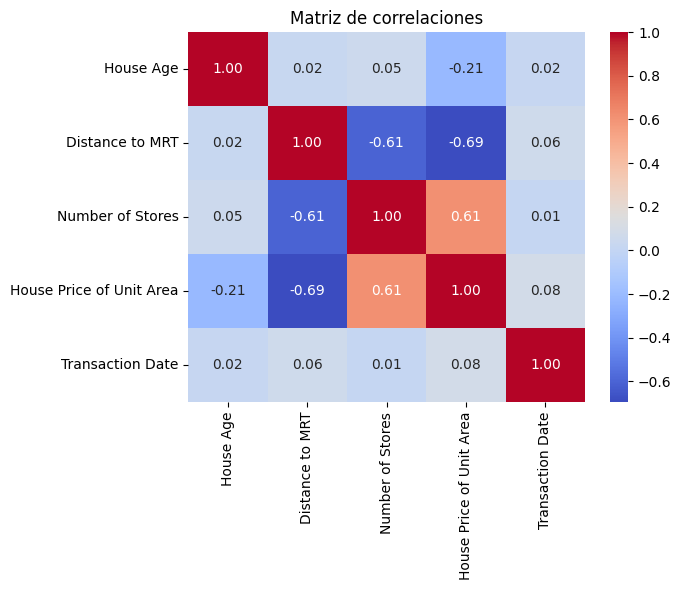

In [395]:
sns.heatmap(df[['House Age', 'Distance to MRT', 'Number of Stores', 
                 'House Price of Unit Area', 'Transaction Date']].corr(), 
            annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de correlaciones')
plt.show()

In [396]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

variables = [col for col in df_train_analisis.columns if col != 'House Price of Unit Area']  # todas menos el target
X_vif = df_train_analisis[variables]

vif = pd.DataFrame()
vif["Variable"] = variables
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif.sort_values("VIF", ascending=False))

             Variable       VIF
0             log_MRT  4.326337
3    mrt_stores_score  2.922681
4  cluster_price_mean  2.696749
5         geo_cluster  1.477561
1          square_age  1.202158
2    Transaction Date  1.018611


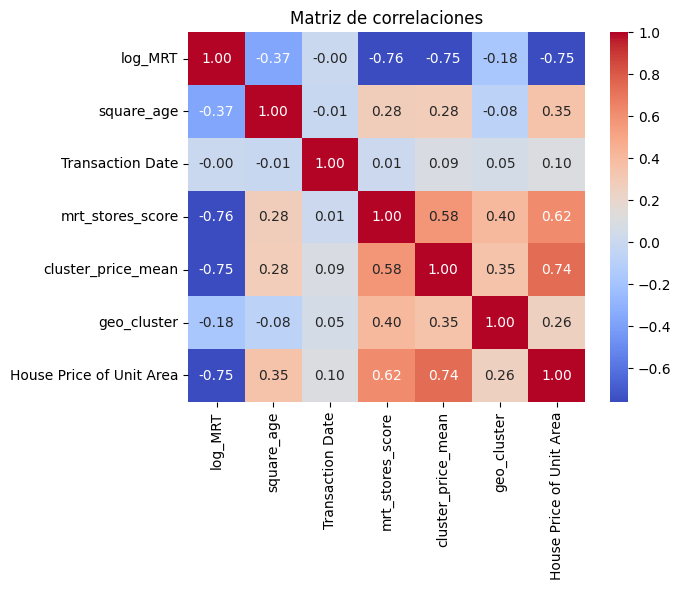

In [397]:
sns.heatmap(df_train_analisis.corr(), 
            annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de correlaciones')
plt.show()

In [398]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

variables = [col for col in df_train_analisis.columns if col != 'House Price of Unit Area' and col != 'House Age' and col != 'Number of Stores' and col != 'Transaction Date']  # todas menos el target
X_vif = df_train_analisis[variables]

vif = pd.DataFrame()
vif["Variable"] = variables
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif.sort_values("VIF", ascending=False))

             Variable       VIF
0             log_MRT  4.302157
2    mrt_stores_score  2.922551
3  cluster_price_mean  2.655317
4         geo_cluster  1.477545
1          square_age  1.201908


In [399]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

def evaluar_modelo(nombre, y, y_pred, X):
    n_features = X.shape[1]
    r2   = r2_score(y, y_pred)
    r2_adj = 1 - (1 - r2) * (len(y) - 1) / (len(y) - n_features - 1)
    mape = np.mean(np.abs((y - y_pred) / y)) * 100
    mae  = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    print(f"── {nombre} ──")
    print(f"R²:   {r2:.4f}")
    print(f"R² Adj:  {r2_adj:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE:{mape:.2f}%")
    return {'modelo': nombre, 'r2': r2, 'mae': mae, 'rmse': rmse}

def comparar_modelos(resultados_train, resultados_test):
    brecha = resultados_train['r2'] - resultados_test['r2']
    print(f"Brecha R²: {brecha:.4f}")

In [400]:
X_train_t = feature_pipeline.transform(X_train)
X_test_t  = feature_pipeline.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_t, y_train)

y_pred_train_lin = lr.predict(X_train_t)
y_pred_test_lin  = lr.predict(X_test_t)

evaluar_modelo("Regresión Lineal Train", y_train, y_pred_train_lin, X_train);
evaluar_modelo("Regresión Lineal Test",  y_test,  y_pred_test_lin,  X_test);


── Regresión Lineal Train ──
R²:   0.6518
R² Adj:  0.6405
MAE:  5.6422
RMSE: 7.5951
MAPE:17.71%
── Regresión Lineal Test ──
R²:   0.6546
R² Adj:  0.6274
MAE:  5.7638
RMSE: 7.8574
MAPE:15.51%


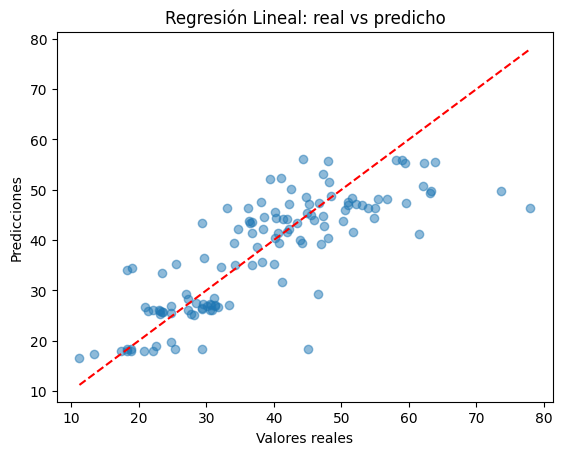

In [401]:
X_test_t = feature_pipeline.transform(X_test)
y_pred = lr.predict(X_test_t)

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Regresión Lineal: real vs predicho")
plt.show()

In [402]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'model': [RandomForestRegressor(random_state=42)],
    'model__n_estimators': [400, 500], # Más árboles para estabilizar el promedio de las predicciones
    
    # 1. Devolvemos una profundidad intermedia óptima para que recupere poder de predicción
    'model__max_depth': [6, 7], 
    
    # 2. Hojas moderadas para que no flote en el underfitting
    'model__min_samples_leaf': [8, 12], 
    'model__min_samples_split': [20,25],
    
    # 3. EL AJUSTE CLAVE: Cada división solo puede elegir entre una fracción de tus variables.
    # Evita que el modelo dependa siempre de la misma variable dominante y reduce el Train de forma drástica.
    'model__max_features': ['sqrt', 0.4, 0.5] 
}

grid_rf = GridSearchCV(
    estimator=feature_pipeline, # Tu pipeline original
    param_grid=param_grid_rf, 
    cv=tscv, 
    scoring='r2', 
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)

y_pred_rf_train = grid_rf.best_estimator_.predict(X_train)
y_pred_rf_test = grid_rf.best_estimator_.predict(X_test)

print(f" Mejores parámetros RF definitivos: {grid_rf.best_params_}");
evaluar_modelo("Random Forest Final (Train)", y_train, y_pred_rf_train, X_train);
evaluar_modelo("Random Forest Final (Test)", y_test, y_pred_rf_test, X_test);
r2_cv_porcentaje = grid_rf.best_score_ * 100
print(f"R² Medio de Cross Validation (CV): {r2_cv_porcentaje:.2f}%");

Fitting 3 folds for each of 48 candidates, totalling 144 fits
 Mejores parámetros RF definitivos: {'model': RandomForestRegressor(random_state=42), 'model__max_depth': 6, 'model__max_features': 0.5, 'model__min_samples_leaf': 8, 'model__min_samples_split': 20, 'model__n_estimators': 400}
── Random Forest Final (Train) ──
R²:   0.7674
R² Adj:  0.7599
MAE:  4.5514
RMSE: 6.2080
MAPE:13.94%
── Random Forest Final (Test) ──
R²:   0.6698
R² Adj:  0.6437
MAE:  5.8841
RMSE: 7.6834
MAPE:15.24%
R² Medio de Cross Validation (CV): 60.96%


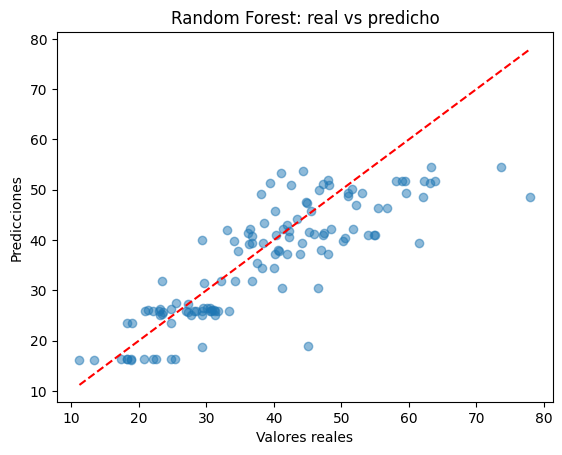

In [423]:
y_pred_rf = grid_rf.best_estimator_.predict(X_test)

plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Random Forest: real vs predicho")
plt.show()

In [404]:
from sklearn.ensemble import GradientBoostingRegressor

param_grid_gb = {
    'model': [GradientBoostingRegressor(random_state=42)],
    'model__learning_rate':     [0.03],
    'model__n_estimators':      [95],
    'model__max_depth':         [3],
    'model__subsample':         [0.6],
    'model__max_features':  [0.7]}

grid_gb = GridSearchCV(
    estimator=feature_pipeline,  # Usando tu nombre original
    param_grid=param_grid_gb, 
    cv=tscv, 
    scoring='r2', 
    n_jobs=-1,
    verbose=1
)
grid_gb.fit(X_train, y_train)

y_pred_gb_train = grid_gb.best_estimator_.predict(X_train);
y_pred_gb_test = grid_gb.best_estimator_.predict(X_test);

print(f"Mejores parámetros GB: {grid_gb.best_params_}")
evaluar_modelo("Gradient Boosting Optimizado (Train)", y_train, y_pred_gb_train, X_train);
evaluar_modelo("Gradient Boosting Optimizado (Test)", y_test, y_pred_gb_test, X_test);
r2_cv_porcentaje = grid_gb.best_score_ * 100
print(f"R² Medio de Cross Validation (CV): {r2_cv_porcentaje:.2f}%");

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Mejores parámetros GB: {'model': GradientBoostingRegressor(random_state=42), 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__max_features': 0.7, 'model__n_estimators': 95, 'model__subsample': 0.6}
── Gradient Boosting Optimizado (Train) ──
R²:   0.8307
R² Adj:  0.8252
MAE:  4.0830
RMSE: 5.2960
MAPE:12.61%
── Gradient Boosting Optimizado (Test) ──
R²:   0.7083
R² Adj:  0.6853
MAE:  5.5094
RMSE: 7.2213
MAPE:14.15%
R² Medio de Cross Validation (CV): 64.44%


In [405]:
# Rendimiento sin los extremos
mask = (y_test >= 15) & (y_test <= 65)
y_pred_test = grid_gb.predict(X_test)

from sklearn.metrics import r2_score
print("R² test completo:     ", round(r2_score(y_test, y_pred_test), 4))
print("R² test sin extremos: ", round(r2_score(y_test[mask], y_pred_test[mask]), 4))

R² test completo:      0.7083
R² test sin extremos:  0.7023


In [406]:
y_pred_test = grid_gb.predict(X_test)
residuals = y_test - y_pred_test

print("Sesgo (media residuos):", residuals.mean().round(2))
print("Dispersión (std):      ", residuals.std().round(2))
print("Errores grandes >15:   ", (residuals.abs() > 15).sum())
print()
print("Target test:\n", y_test.describe().round(2))
print("Target train:\n", y_train.describe().round(2))

Sesgo (media residuos): 2.37
Dispersión (std):       6.85
Errores grandes >15:    3

Target test:
 count    124.00
mean      38.46
std       13.42
min       11.20
25%       28.32
50%       38.30
75%       47.30
max       78.00
Name: House Price of Unit Area, dtype: float64
Target train:
 count    289.00
mean      37.50
std       12.89
min        7.60
25%       27.00
50%       38.50
75%       46.10
max       78.30
Name: House Price of Unit Area, dtype: float64


GB = learning_rate: 0.04, max_depth: 3, max_features: 0.8, n_estimators: 120, subsample: 0.8

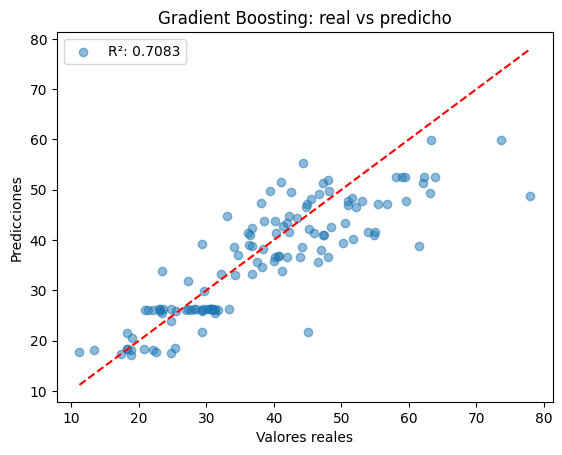

In [407]:
plt.scatter(y_test, y_pred_gb_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Gradient Boosting: real vs predicho")
plt.legend([f"R²: {r2_score(y_test, y_pred_gb_test):.4f}"])
plt.show()

In [408]:
# ============================================================================
# APARTADO: SUPPORT VECTOR REGRESSOR (SVR)
# ============================================================================
from sklearn.svm import SVR

param_grid_svr = {
    'model': [SVR(kernel='rbf')],  
    'model__C':       [50, 100, 200],
    'model__epsilon': [0.1, 0.2, 0.3],
    'model__gamma':   ['scale',0.03],
}

grid_svr = GridSearchCV(
    estimator=feature_pipeline,  # Usando tu nombre original
    param_grid=param_grid_svr, 
    cv=tscv, 
    scoring='r2', 
    n_jobs=-1,
    verbose=1
)
grid_svr.fit(X_train, y_train)

y_pred_svr_train = grid_svr.best_estimator_.predict(X_train)
y_pred_svr_test = grid_svr.best_estimator_.predict(X_test)

print(f"Mejores parámetros SVR: {grid_svr.best_params_}")
evaluar_modelo("SVR Optimizado (Train)", y_train, y_pred_svr_train, X_train); 
evaluar_modelo("SVR Optimizado (Test)", y_test, y_pred_svr_test, X_test);
r2_cv_porcentaje = grid_svr.best_score_ * 100
print(f"R² Medio de Cross Validation (CV): {r2_cv_porcentaje:.2f}%");

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Mejores parámetros SVR: {'model': SVR(), 'model__C': 50, 'model__epsilon': 0.3, 'model__gamma': 0.03}
── SVR Optimizado (Train) ──
R²:   0.6867
R² Adj:  0.6766
MAE:  5.0135
RMSE: 7.2038
MAPE:15.82%
── SVR Optimizado (Test) ──
R²:   0.6587
R² Adj:  0.6317
MAE:  5.6708
RMSE: 7.8115
MAPE:15.55%
R² Medio de Cross Validation (CV): 51.99%



📌 Mejores parámetros SVR: {'model': SVR(), 'model__C': 50, 'model__epsilon': 0.3, 'model__gamma': 0.03}


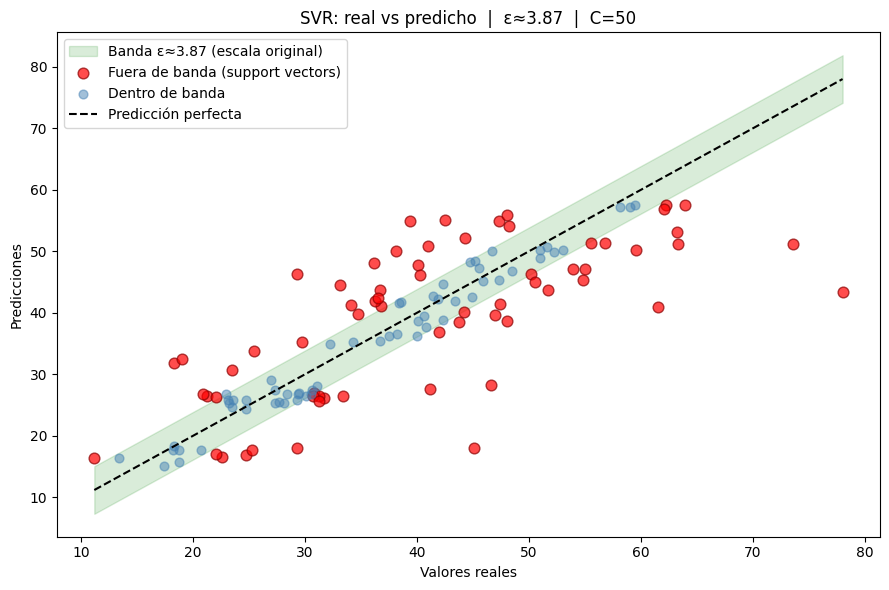

Puntos dentro de banda ε: 59 (47.6%)
Support vectors aprox.:   65


In [409]:
import matplotlib.pyplot as plt
import numpy as np

y_pred_test = grid_svr.predict(X_test)
y_std = y_train.std()
epsilon_original = grid_svr.best_params_['model__epsilon'] * y_std

residuos = y_test.values - y_pred_test
dentro_banda = np.abs(residuos) <= epsilon_original

x_line = np.linspace(y_test.min(), y_test.max(), 100)

plt.figure(figsize=(9, 6))
plt.fill_between(x_line, x_line - epsilon_original, x_line + epsilon_original,
                 alpha=0.15, color='green',
                 label=f'Banda ε≈{epsilon_original:.2f} (escala original)')
plt.scatter(y_test[~dentro_banda], y_pred_test[~dentro_banda],
            alpha=0.7, color='red', edgecolors='darkred', s=60,
            label='Fuera de banda (support vectors)')
plt.scatter(y_test[dentro_banda], y_pred_test[dentro_banda],
            alpha=0.5, color='steelblue', s=40,
            label='Dentro de banda')
plt.plot(x_line, x_line, 'k--', linewidth=1.5, label='Predicción perfecta')
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title(f"SVR: real vs predicho  |  ε≈{epsilon_original:.2f}  |  C={grid_svr.best_params_['model__C']}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Puntos dentro de banda ε: {dentro_banda.sum()} ({dentro_banda.mean()*100:.1f}%)")
print(f"Support vectors aprox.:   {(~dentro_banda).sum()}")

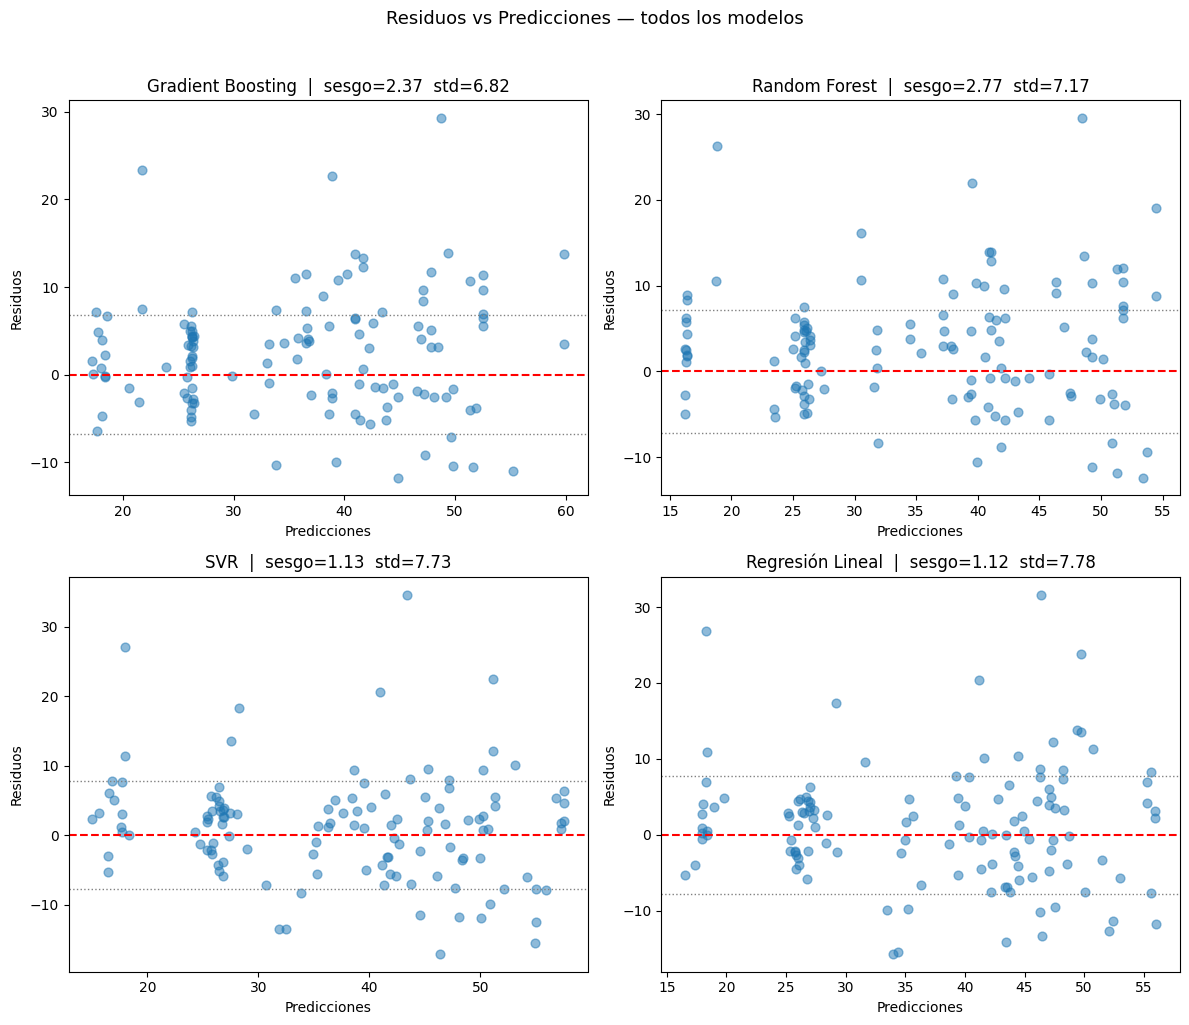

In [410]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

modelos = [
    (grid_gb,  X_test, "Gradient Boosting"),
    (grid_rf,  X_test, "Random Forest"),
    (grid_svr, X_test, "SVR"),
    (lr,       X_test_t, "Regresión Lineal"),
]

for ax, (modelo, X, nombre) in zip(axes.flatten(), modelos):
    y_pred = modelo.predict(X)
    residuos = y_test.values - y_pred

    ax.scatter(y_pred, residuos, alpha=0.5, s=40)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.axhline( residuos.std(), color='gray', linestyle=':', linewidth=1)
    ax.axhline(-residuos.std(), color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel("Predicciones")
    ax.set_ylabel("Residuos")
    ax.set_title(f"{nombre}  |  sesgo={residuos.mean():.2f}  std={residuos.std():.2f}")

plt.suptitle("Residuos vs Predicciones — todos los modelos", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [424]:
from sklearn.ensemble import VotingRegressor

ensamble = VotingRegressor(estimators=[
    ('gb',  grid_gb.best_estimator_),
    ('svr', grid_svr.best_estimator_),
    ('lr',  lr),
], weights=[4.5, 3, 1.5])  # Más peso a los modelos con mejor test

ensamble.fit(X_train, y_train)

y_pred_ens_train = ensamble.predict(X_train)
y_pred_ens_test  = ensamble.predict(X_test)

evaluar_modelo("Ensamble (Train)", y_train, y_pred_ens_train, X_train);
evaluar_modelo("Ensamble (Test)",  y_test,  y_pred_ens_test,  X_test);

── Ensamble (Train) ──
R²:   0.7842
R² Adj:  0.7772
MAE:  4.3622
RMSE: 5.9791
MAPE:13.54%
── Ensamble (Test) ──
R²:   0.7118
R² Adj:  0.6890
MAE:  5.3402
RMSE: 7.1778
MAPE:14.23%


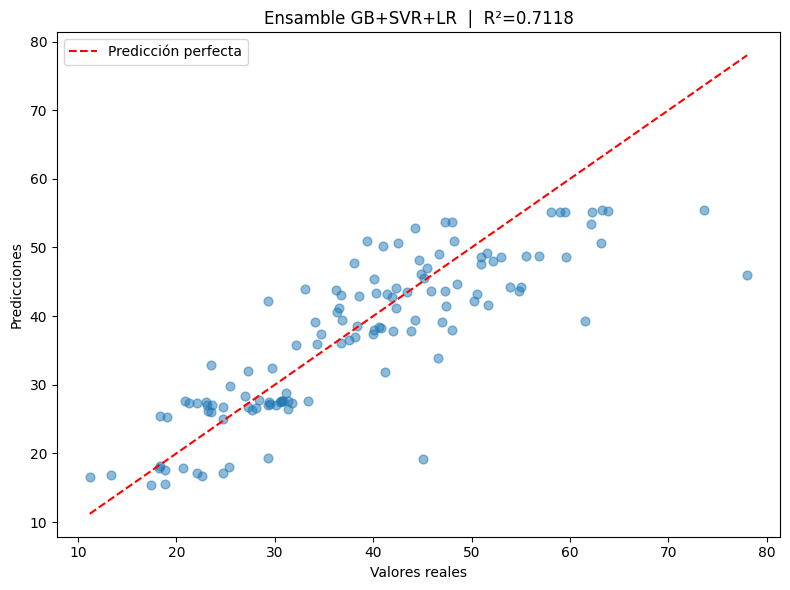

In [412]:
plt.figure(figsize=(8, 6))
x_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.scatter(y_test, y_pred_ens_test, alpha=0.5, s=40)
plt.plot(x_line, x_line, 'r--', linewidth=1.5, label='Predicción perfecta')
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title(f"Ensamble GB+SVR+LR  |  R²={round(r2_score(y_test, y_pred_ens_test), 4)}")
plt.legend()
plt.tight_layout()
plt.show()

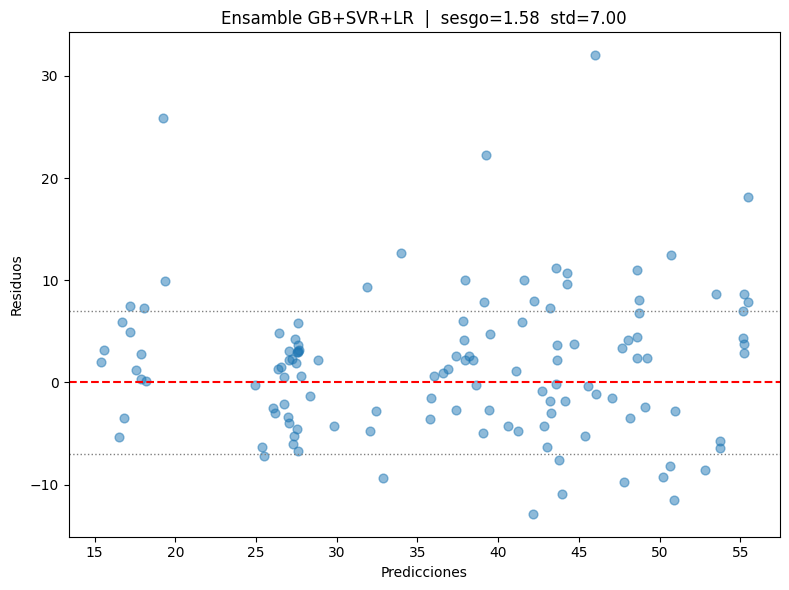

In [413]:
y_pred_ens_test = ensamble.predict(X_test)
residuos_ens = y_test.values - y_pred_ens_test

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_ens_test, residuos_ens, alpha=0.5, s=40)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.axhline( residuos_ens.std(), color='gray', linestyle=':', linewidth=1)
plt.axhline(-residuos_ens.std(), color='gray', linestyle=':', linewidth=1)
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title(f"Ensamble GB+SVR+LR  |  sesgo={residuos_ens.mean():.2f}  std={residuos_ens.std():.2f}")
plt.tight_layout()
plt.show()

In [414]:
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

# 1. RMSE de CV — estimación honesta del error esperado en producción
cv_scores = cross_val_score(ensamble, X_train, y_train,
                             cv=tscv, scoring='neg_mean_squared_error')
rmse_cv = np.sqrt(-cv_scores.mean())
print(f"RMSE CV (estimación producción): {rmse_cv:.4f}")

# 2. RMSE real en train y test (referencia)
rmse_train = np.sqrt(mean_squared_error(y_train, ensamble.predict(X_train)))
rmse_test  = np.sqrt(mean_squared_error(y_test,  ensamble.predict(X_test)))
print(f"RMSE Train:                      {rmse_train:.4f}")
print(f"RMSE Test:                       {rmse_test:.4f}")

# =========================================================================
# FUNCIÓN DE PRODUCCIÓN: Intervalos de Predicción
# =========================================================================
def predecir_con_intervalo(model, X_nuevo, rmse, confianza=0.95):
    """
    Calcula intervalo de predicción usando el RMSE de CV como estimación
    del error esperado en datos nuevos.
    confianza=0.95 → multiplicador 1.96
    confianza=0.90 → multiplicador 1.645
    confianza=0.99 → multiplicador 2.576
    """
    from scipy import stats
    z = stats.norm.ppf((1 + confianza) / 2)
    pred     = model.predict(X_nuevo)
    banda_inf = pred - z * rmse
    banda_sup = pred + z * rmse
    return pred, banda_inf, banda_sup

# =========================================================================
# EJECUCIÓN: 5 primeras casas del test
# =========================================================================
X_ejemplo = X_test[:5]
y_real_ejemplo = y_test.iloc[:5].values if hasattr(y_test, 'values') else y_test[:5]

pred, inf, sup = predecir_con_intervalo(ensamble, X_ejemplo, rmse_cv)

print("\n🏆 INFORME DE TASACIÓN (95% DE COBERTURA):")
print("-" * 80)
for i in range(len(X_ejemplo)):
    dentro = "✅" if inf[i] <= y_real_ejemplo[i] <= sup[i] else "❌"
    print(f"Casa {i+1} → Real: {y_real_ejemplo[i]:.2f} | "
          f"Pred: {pred[i]:.2f} | "
          f"Intervalo: [{inf[i]:.2f} – {sup[i]:.2f}] {dentro}")
print("-" * 80)

RMSE CV (estimación producción): 7.6788
RMSE Train:                      5.9791
RMSE Test:                       7.1778

🏆 INFORME DE TASACIÓN (95% DE COBERTURA):
--------------------------------------------------------------------------------
Casa 1 → Real: 73.60 | Pred: 55.46 | Intervalo: [40.41 – 70.51] ❌
Casa 2 → Real: 40.00 | Pred: 37.36 | Intervalo: [22.31 – 52.41] ✅
Casa 3 → Real: 33.10 | Pred: 43.97 | Intervalo: [28.92 – 59.02] ✅
Casa 4 → Real: 43.40 | Pred: 43.56 | Intervalo: [28.51 – 58.61] ✅
Casa 5 → Real: 30.50 | Pred: 27.53 | Intervalo: [12.48 – 42.58] ✅
--------------------------------------------------------------------------------


In [415]:
y_pred_train_lin  = lr.predict(X_train_t)
y_pred_test_lin   = lr.predict(X_test_t)
y_pred_rf_train   = grid_rf.best_estimator_.predict(X_train)
y_pred_rf_test    = grid_rf.best_estimator_.predict(X_test)
y_pred_gb_train   = grid_gb.best_estimator_.predict(X_train)
y_pred_gb_test    = grid_gb.best_estimator_.predict(X_test)
y_pred_svr_train  = grid_svr.best_estimator_.predict(X_train)
y_pred_svr_test   = grid_svr.best_estimator_.predict(X_test)
y_pred_ens_train  = ensamble.predict(X_train)
y_pred_ens_test   = ensamble.predict(X_test)

In [416]:
resultados_train = [
    evaluar_modelo("Regresión Lineal Train", y_train, y_pred_train_lin, X_train),
    evaluar_modelo("RF Tuned Train",         y_train, y_pred_rf_train,  X_train),
    evaluar_modelo("GB Tuned Train",         y_train, y_pred_gb_train,  X_train),
    evaluar_modelo("SVR Tuned Train",        y_train, y_pred_svr_train, X_train),
    evaluar_modelo("Ensemble Train",         y_train, y_pred_ens_train, X_train),
]

resultados_test = [
    evaluar_modelo("Regresión Lineal Test", y_test, y_pred_test_lin,  X_test),
    evaluar_modelo("RF Tuned Test",         y_test, y_pred_rf_test,   X_test),
    evaluar_modelo("GB Tuned Test",         y_test, y_pred_gb_test,   X_test),
    evaluar_modelo("SVR Tuned Test",        y_test, y_pred_svr_test,  X_test),
    evaluar_modelo("Ensemble Test",         y_test, y_pred_ens_test,  X_test),
]

df_train = pd.DataFrame(resultados_train)
df_test  = pd.DataFrame(resultados_test)

── Regresión Lineal Train ──
R²:   0.6518
R² Adj:  0.6405
MAE:  5.6422
RMSE: 7.5951
MAPE:17.71%
── RF Tuned Train ──
R²:   0.7674
R² Adj:  0.7599
MAE:  4.5514
RMSE: 6.2080
MAPE:13.94%
── GB Tuned Train ──
R²:   0.8307
R² Adj:  0.8252
MAE:  4.0830
RMSE: 5.2960
MAPE:12.61%
── SVR Tuned Train ──
R²:   0.6867
R² Adj:  0.6766
MAE:  5.0135
RMSE: 7.2038
MAPE:15.82%
── Ensemble Train ──
R²:   0.7842
R² Adj:  0.7772
MAE:  4.3622
RMSE: 5.9791
MAPE:13.54%
── Regresión Lineal Test ──
R²:   0.6546
R² Adj:  0.6274
MAE:  5.7638
RMSE: 7.8574
MAPE:15.51%
── RF Tuned Test ──
R²:   0.6698
R² Adj:  0.6437
MAE:  5.8841
RMSE: 7.6834
MAPE:15.24%
── GB Tuned Test ──
R²:   0.7083
R² Adj:  0.6853
MAE:  5.5094
RMSE: 7.2213
MAPE:14.15%
── SVR Tuned Test ──
R²:   0.6587
R² Adj:  0.6317
MAE:  5.6708
RMSE: 7.8115
MAPE:15.55%
── Ensemble Test ──
R²:   0.7118
R² Adj:  0.6890
MAE:  5.3402
RMSE: 7.1778
MAPE:14.23%


In [417]:
df_comparativa = df_test.copy()
df_comparativa['brecha_r2'] = df_train['r2'].values - df_test['r2'].values
df_comparativa.drop(columns=['mae', 'rmse', 'r2'], inplace=True)

print(df_comparativa)
print(df_train)
print(df_test)

                  modelo  brecha_r2
0  Regresión Lineal Test  -0.002850
1          RF Tuned Test   0.097596
2          GB Tuned Test   0.122407
3         SVR Tuned Test   0.028085
4          Ensemble Test   0.072406
                   modelo        r2       mae      rmse
0  Regresión Lineal Train  0.651781  5.642176  7.595131
1          RF Tuned Train  0.767357  4.551359  6.208032
2          GB Tuned Train  0.830693  4.082990  5.295988
3         SVR Tuned Train  0.686744  5.013496  7.203754
4          Ensemble Train  0.784197  4.362189  5.979131
                  modelo        r2       mae      rmse
0  Regresión Lineal Test  0.654630  5.763807  7.857415
1          RF Tuned Test  0.669761  5.884087  7.683368
2          GB Tuned Test  0.708286  5.509358  7.221319
3         SVR Tuned Test  0.658659  5.670773  7.811454
4          Ensemble Test  0.711791  5.340225  7.177806


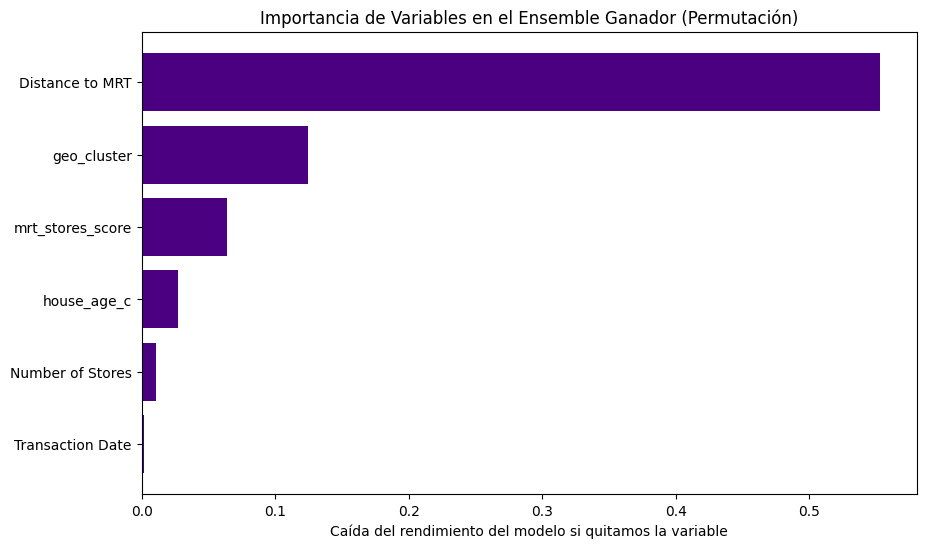

In [418]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# 1. Pon aquí el nombre exacto de tu objeto Ensemble (el que usaste para hacer el .fit)
modelo_ganador = ensamble  # REEMPLAZA con el nombre de tu modelo final (ej: ensemble_final, mejor_ensamble, etc.)

# 2. Calculamos la importancia por permutación en el set de TEST
resultado = permutation_importance(
    modelo_ganador, X_test, y_test, n_repeats=10, random_state=42
)

# CORRECTO — no toques features_inspection antes de crear el DataFrame

features_inspection = X_test.columns.tolist()  # todos — coincide con importances_mean

df_perm = pd.DataFrame({
    'Variable': features_inspection,
    'Importancia': resultado.importances_mean
})

# ✅ filtra el df ya construido, no la lista de nombres
df_perm = df_perm[~df_perm['Variable'].isin(['Longitude', 'Latitude', 'House Age'])]
df_perm = df_perm.sort_values('Importancia', ascending=True)

# 4. Graficamos
plt.figure(figsize=(10, 6))
plt.barh(df_perm['Variable'], df_perm['Importancia'], color='indigo')
plt.xlabel('Caída del rendimiento del modelo si quitamos la variable')
plt.title('Importancia de Variables en el Ensemble Ganador (Permutación)')
plt.show()

In [419]:
import folium
from folium.plugins import HeatMap
import pandas as pd
import numpy as np

colores_cluster = [
    'red', 'blue', 'green', 'purple', 'orange',
    'darkred', 'cadetblue', 'darkgreen', 'darkpurple'
]

# Precio medio por cluster ordenado
precio_por_cluster = (
    df.groupby('geo_cluster')['House Price of Unit Area']
    .mean()
    .sort_values()
    .reset_index()
)
precio_por_cluster.columns = ['Cluster', 'Precio_Medio']
precio_por_cluster['Ranking'] = range(1, len(precio_por_cluster) + 1)

# Leyenda HTML
leyenda_html = """
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
            background-color: white; padding: 15px; border-radius: 10px;
            border: 2px solid grey; font-family: Arial; font-size: 13px;
            box-shadow: 3px 3px 6px rgba(0,0,0,0.3);">
    <b>Barrios (Clusters) por Precio Medio en Nuevo Dólar de Taiwán (NTD)</b><br>
    <i style="font-size:11px; color:gray;">Ordenados de menor a mayor</i><br><br>
"""

for _, row in precio_por_cluster.iterrows():
    cluster_id = int(row['Cluster'])
    color = colores_cluster[cluster_id % len(colores_cluster)]
    leyenda_html += (                          # ← aquí
        f"<span style='color:{color}; font-size:18px;'>●</span> "
        f"Barrio {cluster_id} — {row['Precio_Medio']:.1f} NTD/ping "
        f"({row['Precio_Medio'] / 3.3058:.1f} NTD/m²) "
        f"<span style='color:gray;'>(#{int(row['Ranking'])})</span><br>"
    )

leyenda_html += "</div>"

# Mapa
coordenadas_centro = [df['Latitude'].mean(), df['Longitude'].mean()]
mapa = folium.Map(location=coordenadas_centro, zoom_start=14, tiles="OpenStreetMap")

# Clusters
for idx, row in df.iterrows():
    cluster_id = int(row['geo_cluster'])
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        color=colores_cluster[cluster_id % len(colores_cluster)],
        fill=True,
        fill_color=colores_cluster[cluster_id % len(colores_cluster)],
        fill_opacity=0.6,
        popup=(
            f"Barrio {cluster_id}<br>"
            f"Precio medio: {row['cluster_price_mean']:.1f} NTD/ping "
            f"({row['cluster_price_mean'] / 3.3058:.1f} NTD/m²)<br>"
            f"Precio real: {row['House Price of Unit Area']:.1f} NTD/ping "
            f"({row['House Price of Unit Area'] / 3.3058:.1f} NTD/m²)"
        )
    ).add_to(mapa)

# Añadir leyenda
mapa.get_root().html.add_child(folium.Element(leyenda_html))

mapa.save("mapa_clusters.html")
mapa